

## Setup — Install Libraries

In [ ]:
!pip install matplotlib numpy scikit-learn scipy torch tqdm -q
print("All libraries ready.")

All libraries ready.


## FR1 — Data Loading & Preprocessing
Upload your `MSNet-main.zip`, extract it, and preprocess the hyperspectral data.

In [ ]:
from google.colab import files
uploaded = files.upload()   # Upload MSNet-main.zip
!unzip -q MSNet-main.zip
%cd MSNet-main
!ls


Saving MSNet-main.zip to MSNet-main.zip
/content/MSNet-main
dataset  main.py    model      README.md	 select_bands.py  utils.py
LICENSE  metric.py  MSNet.png  requirements.txt  SeT


In [ ]:
import scipy.io as sio, numpy as np, os
import select_bands, utils

# Load dataset
from dataset import coast
data, gt = coast.get_data()
rows, cols, bands = data.shape

print(f"Dataset      : {coast.name}")
print(f"Image shape  : {rows} x {cols} x {bands} spectral bands")
print(f"Total pixels : {rows*cols}")
print(f"Anomaly pixels: {gt.sum()} ({100*gt.sum()/(rows*cols):.2f}%)")

# FR1 core: OPBS band selection + Z-Score normalisation
num_bs   = 64
band_idx = select_bands.OPBS(data, num_bs)
data_bs  = data[:, :, band_idx]
data_bs  = utils.ZScoreNorm().fit(data_bs).transform(data_bs)

print(f"\nFR1 COMPLETE")
print(f"  Bands selected by OPBS : {num_bs} / {bands}")
print(f"  Data normalised (Z-Score): mean≈0, std≈1 per band")


Dataset      : coast
Image shape  : 100 x 100 x 204 spectral bands
Total pixels : 10000
Anomaly pixels: 67 (0.67%)

FR1 COMPLETE
  Bands selected by OPBS : 64 / 204
  Data normalised (Z-Score): mean≈0, std≈1 per band


## FR2 — Anomaly Detection (MSNet + Separation Training)
Train the multiscale encoder-decoder and detect anomaly pixels via reconstruction error.

In [ ]:
import torch
from torch.optim import Adam
from model import MSNet
from SeT import TotalLoss, Mask, separation_training
import metric

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

lmda, num_layers, lr   = 1e-3, 3, 1e-3
epochs, output_iter, max_iter = 150, 5, 10

net_kwargs = dict(num_layers=num_layers, shape=(rows, cols, num_bs))
model      = MSNet(**net_kwargs).to(device).float()
loss_fn    = TotalLoss(lmda, device)
mask       = Mask((rows, cols), device)
optimizer  = Adam(model.parameters(), lr=lr)
x_bs       = torch.from_numpy(data_bs).to(device).float()

print(f"Model      : MSNet ({num_layers} encoder-decoder layers)")
print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")
print(f"Training   : {max_iter} iterations x {epochs} epochs = {max_iter*epochs} total epochs")
print("\nStarting Separation Training...")

pr_dm, history = separation_training(
    x=x_bs, gt=gt, model=model, loss=loss_fn,
    mask=mask, optimizer=optimizer,
    epochs=epochs, output_iter=output_iter,
    max_iter=max_iter, verbose=True
)

rx_dm = utils.rx(data)
_, _, rx_auc = metric.roc_auc(rx_dm, gt)
_, _, pr_auc = metric.roc_auc(pr_dm, gt)

print(f"\nFR2 COMPLETE")
print(f"  RX Detector AUC : {rx_auc:.4f}")
print(f"  MSNet+SeT AUC   : {pr_auc:.4f}  (+{pr_auc-rx_auc:.4f} improvement)")


Device: cuda
Model      : MSNet (3 encoder-decoder layers)
Parameters : 92,976
Training   : 10 iterations x 150 epochs = 1500 total epochs

Starting Separation Training...
Iter 1


100%|██████████| 150/150 [00:02<00:00, 52.94it/s, loss=0.1040]


Current AUC score: 0.9851
Iter 2


100%|██████████| 150/150 [00:01<00:00, 98.21it/s, loss=0.1636]


Current AUC score: 0.9929
Iter 3


...

Current AUC score: 0.9969
Iter 9


100%|██████████| 150/150 [00:01<00:00, 104.57it/s, loss=0.0922]


Current AUC score: 0.9949
Iter 10


100%|██████████| 150/150 [00:01<00:00, 105.48it/s, loss=0.0778]


Current AUC score: 0.9962

FR2 COMPLETE
  RX Detector AUC : 0.9907
  MSNet+SeT AUC   : 0.9969  (+0.0063 improvement)


## FR3 — Visualization of Detection Results
Display anomaly maps, ROC curve, and comparison against the RX baseline.

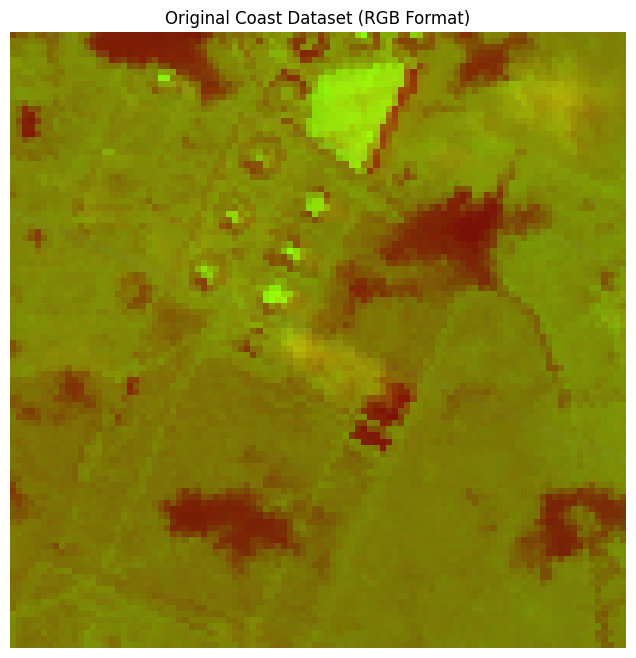

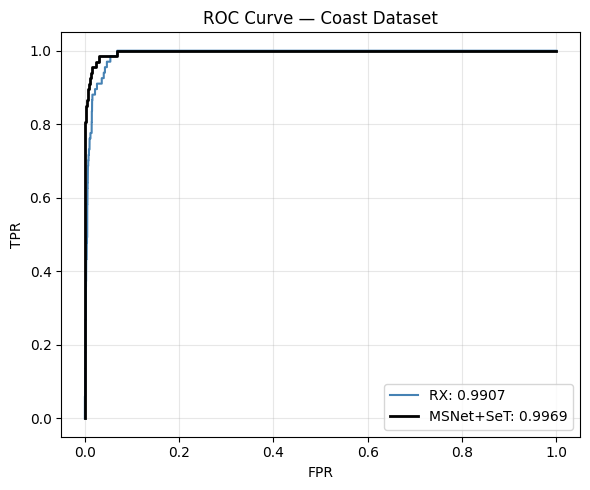

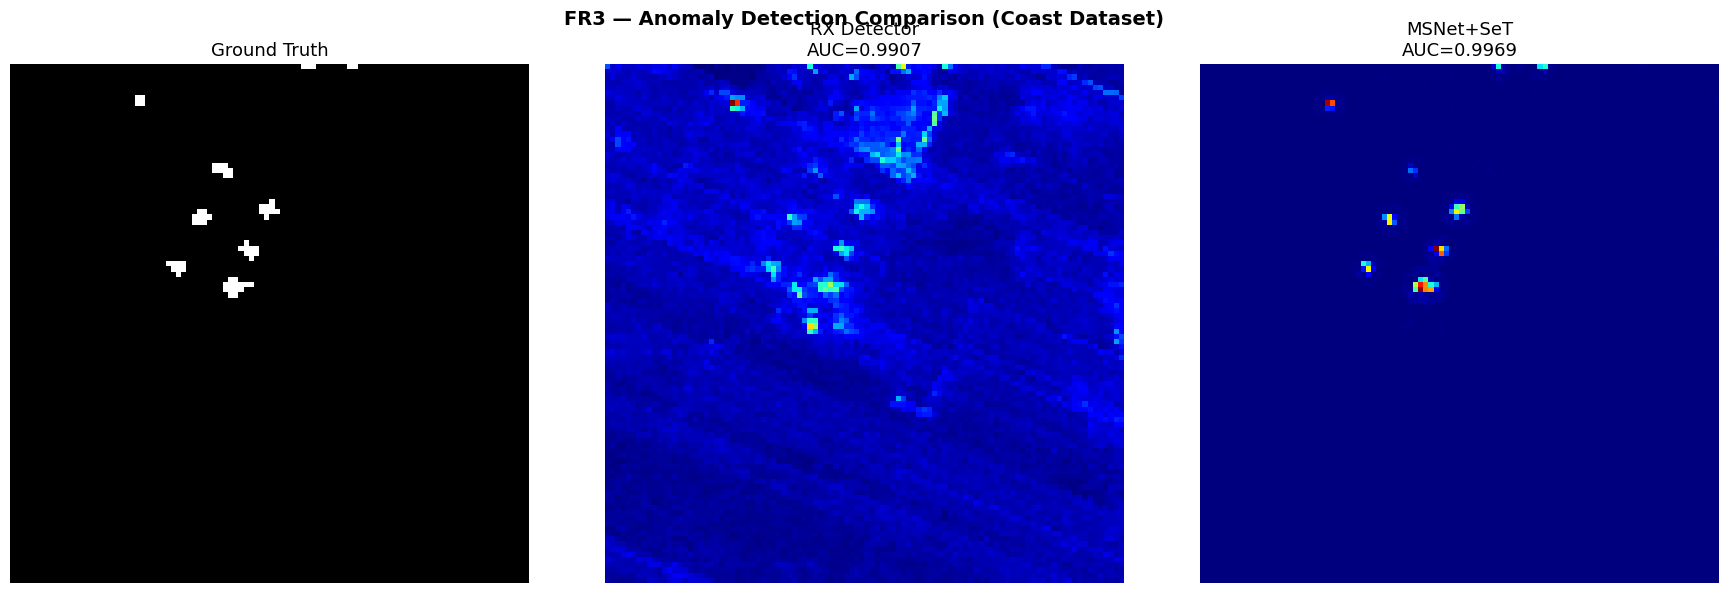

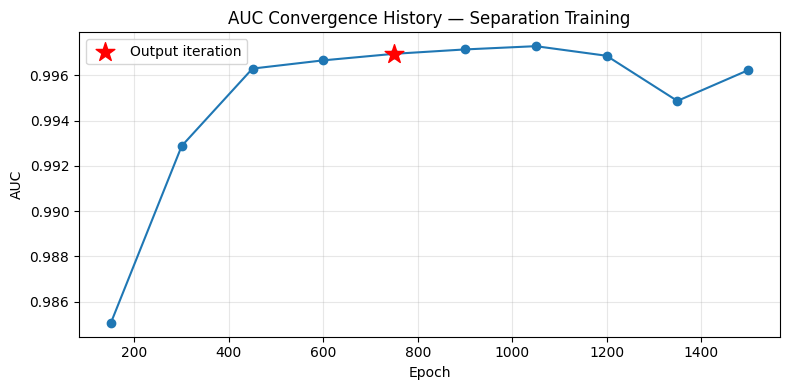

FR3 COMPLETE — all visualisations saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import Image, display
import os

result_path = "results/MSNet"
os.makedirs(result_path, exist_ok=True)

# ── ROC Curve
fpr_rx, tpr_rx, _ = metric.roc_auc(rx_dm, gt)
fpr_pr, tpr_pr, _ = metric.roc_auc(pr_dm, gt)
#

r = data[:, :, band_idx[0]]
g = data[:, :, band_idx[len(band_idx)//2]]
b = data[:, :, band_idx[-1]]

# Stack into RGB image
rgb = np.stack([r, g, b], axis=2)

# Normalize for display
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(8,8))

plt.imshow(rgb)
plt.title('Original Coast Dataset (RGB Format)')
plt.axis('off')

plt.savefig(os.path.join(result_path, 'coast_rgb.png'))
plt.show()


#
plt.figure(figsize=(6,5))
plt.plot(fpr_rx, tpr_rx, label=f"RX: {rx_auc:.4f}", color="steelblue")
plt.plot(fpr_pr, tpr_pr, label=f"MSNet+SeT: {pr_auc:.4f}", color="black", lw=2)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve — Coast Dataset"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/MSNet/coast_roc.png", dpi=150)
plt.show()

# ── Detection Map Comparison
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(gt, cmap="gray");   ax[0].set_title("Ground Truth",            fontsize=13); ax[0].axis("off")
ax[1].imshow(rx_dm, cmap="jet"); ax[1].set_title(f"RX Detector\nAUC={rx_auc:.4f}", fontsize=13); ax[1].axis("off")
ax[2].imshow(pr_dm, cmap="jet"); ax[2].set_title(f"MSNet+SeT\nAUC={pr_auc:.4f}",   fontsize=13); ax[2].axis("off")
plt.suptitle("FR3 — Anomaly Detection Comparison (Coast Dataset)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/MSNet/comparison.png", dpi=150)
plt.show()

# ── AUC History
iters = [(i+1)*epochs for i in range(max_iter)]
plt.figure(figsize=(8,4))
plt.plot(iters, history, marker="o")
plt.scatter([output_iter*epochs],[history[output_iter-1]],
            marker="*", s=200, c="red", zorder=5, label="Output iteration")
plt.xlabel("Epoch"); plt.ylabel("AUC")
plt.title("AUC Convergence History — Separation Training")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/MSNet/auc_history.png", dpi=150)
plt.show()

print("FR3 COMPLETE — all visualisations saved.")

## FR4 — Explainable AI (XAI)
**Gradient-based attribution** to identify:
- Which **spectral bands** drive anomaly detection most
- Which **spatial regions** the model focuses on

Method: Input gradient of total reconstruction error w.r.t. input tensor `x_bs`

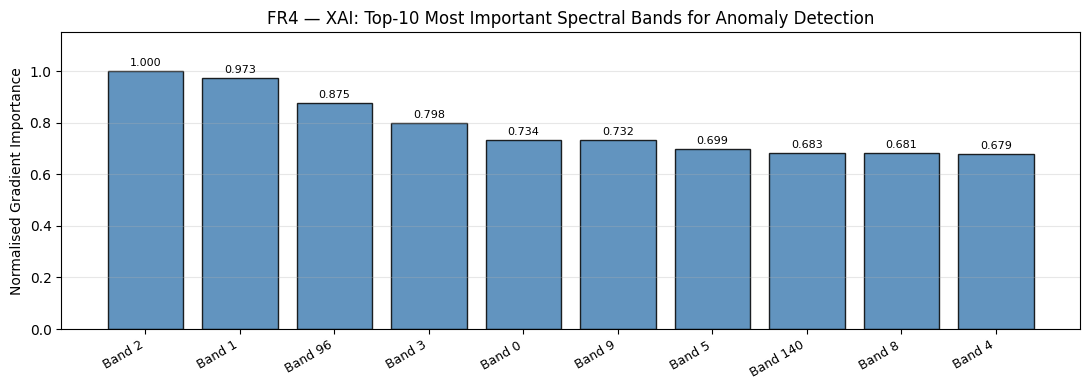

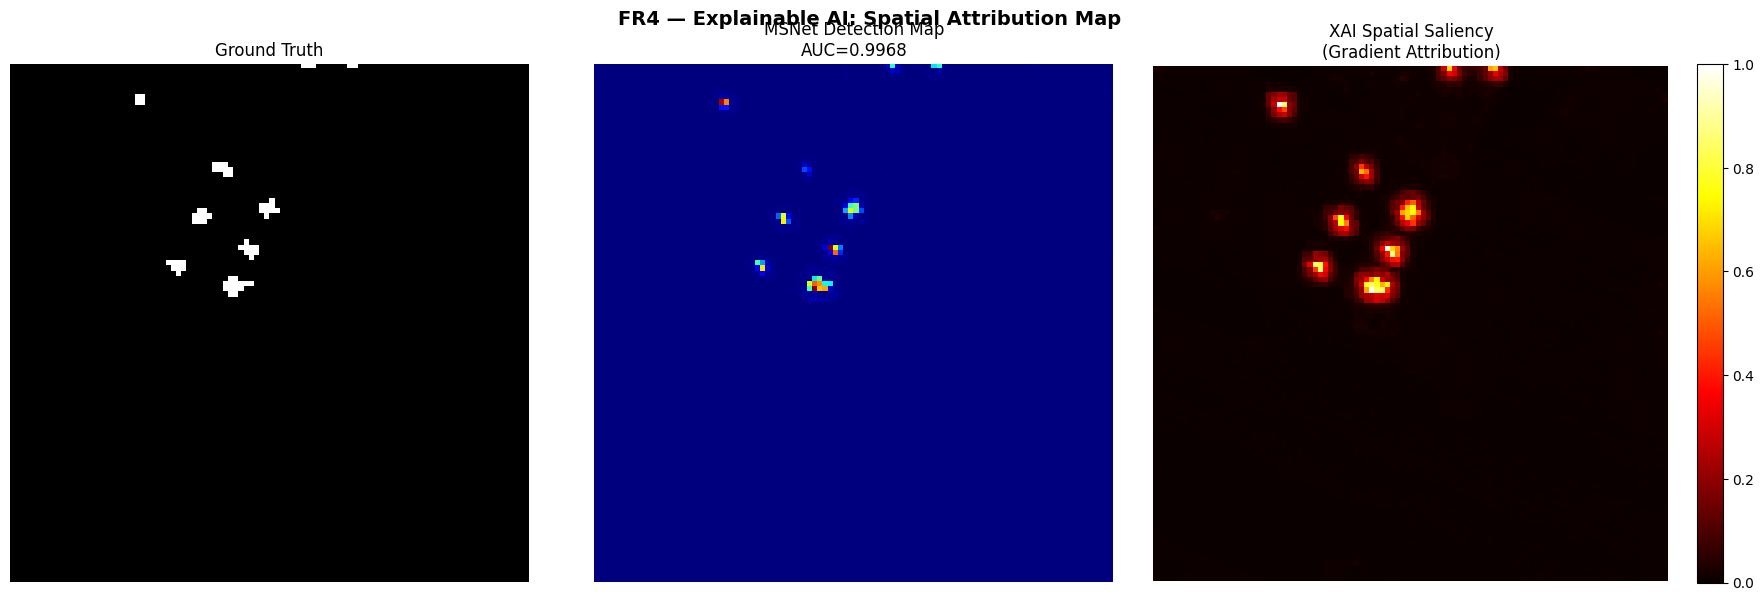

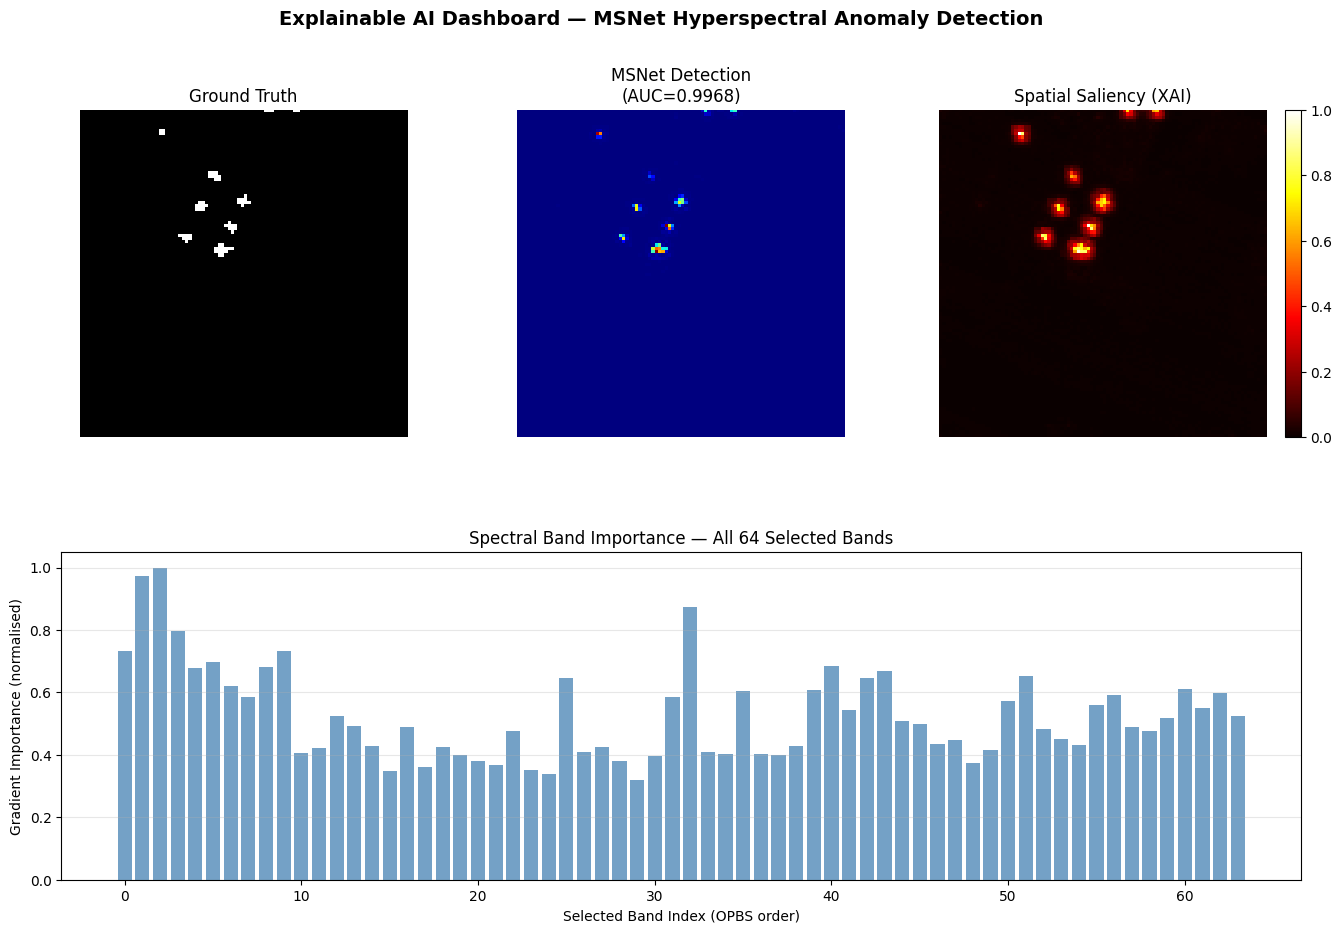


FR4 COMPLETE
  Top anomaly-driving band : Band 2
  Gradient importance score: 1.0000
  Spatial saliency range   : [0.000, 1.000]
  Files saved:
    results/MSNet/xai_band_importance.png
    results/MSNet/xai_spatial_saliency.png
    results/MSNet/xai_dashboard.png


In [ ]:
import matplotlib.gridspec as gridspec

# ── Gradient computation
model.eval()
x_xai = x_bs.clone().detach().requires_grad_(True)
y_xai = model(x_xai)
recon = y_xai[0]                                        # first decoder output
recon_error = ((x_xai - recon) ** 2).sum(dim=2)        # per-pixel anomaly score
recon_error.sum().backward()                            # backprop

band_grads       = x_xai.grad.abs()                    # (rows, cols, bands)
band_importance  = band_grads.mean(dim=(0,1)).cpu().numpy()
band_importance  = band_importance / band_importance.max()

spatial_saliency = band_grads.mean(dim=2).cpu().detach().numpy()
spatial_saliency = (spatial_saliency - spatial_saliency.min()) / \
                   (spatial_saliency.max() - spatial_saliency.min())

top_k    = 10
top_idx  = np.argsort(band_importance)[::-1][:top_k]
top_bands = [band_idx[i] for i in top_idx]
top_vals  = band_importance[top_idx]

# ── Plot 1: Band Importance
fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(top_k), top_vals, color="steelblue", alpha=0.85, edgecolor="black")
ax.set_xticks(range(top_k))
ax.set_xticklabels([f"Band {b}" for b in top_bands], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Normalised Gradient Importance")
ax.set_title("FR4 — XAI: Top-10 Most Important Spectral Bands for Anomaly Detection")
ax.set_ylim(0, 1.15); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, top_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f"{val:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/MSNet/xai_band_importance.png", dpi=150)
plt.show()

# ── Plot 2: Spatial Saliency vs Detection vs Ground Truth
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gt, cmap="gray");           axes[0].set_title("Ground Truth", fontsize=12);                   axes[0].axis("off")
axes[1].imshow(pr_dm, cmap="jet");         axes[1].set_title(f"MSNet Detection Map\nAUC={pr_auc:.4f}", fontsize=12); axes[1].axis("off")
im = axes[2].imshow(spatial_saliency, cmap="hot")
axes[2].set_title("XAI Spatial Saliency\n(Gradient Attribution)", fontsize=12); axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.suptitle("FR4 — Explainable AI: Spatial Attribution Map", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/MSNet/xai_spatial_saliency.png", dpi=150)
plt.show()

# ── Plot 3: Full XAI Dashboard
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35)

a1 = fig.add_subplot(gs[0, 0])
a1.imshow(gt, cmap="gray"); a1.set_title("Ground Truth"); a1.axis("off")

a2 = fig.add_subplot(gs[0, 1])
a2.imshow(pr_dm, cmap="jet"); a2.set_title(f"MSNet Detection\n(AUC={pr_auc:.4f})"); a2.axis("off")

a3 = fig.add_subplot(gs[0, 2])
im3 = a3.imshow(spatial_saliency, cmap="hot")
a3.set_title("Spatial Saliency (XAI)"); a3.axis("off")
plt.colorbar(im3, ax=a3, fraction=0.046)

a4 = fig.add_subplot(gs[1, :])
a4.bar(range(len(band_importance)), band_importance, color="steelblue", alpha=0.75)
a4.set_xlabel("Selected Band Index (OPBS order)")
a4.set_ylabel("Gradient Importance (normalised)")
a4.set_title("Spectral Band Importance — All 64 Selected Bands")
a4.grid(axis="y", alpha=0.3)

plt.suptitle("Explainable AI Dashboard — MSNet Hyperspectral Anomaly Detection",
             fontsize=14, fontweight="bold")
plt.savefig("results/MSNet/xai_dashboard.png", dpi=150)
plt.show()

print("\nFR4 COMPLETE")
print(f"  Top anomaly-driving band : Band {top_bands[0]}")
print(f"  Gradient importance score: {top_vals[0]:.4f}")
print(f"  Spatial saliency range   : [{spatial_saliency.min():.3f}, {spatial_saliency.max():.3f}]")
print("  Files saved:")
print("    results/MSNet/xai_band_importance.png")
print("    results/MSNet/xai_spatial_saliency.png")
print("    results/MSNet/xai_dashboard.png")


Computing Integrated Gradients (50 steps)... this takes ~2 min
Integrated Gradients: DONE
GradCAM: DONE


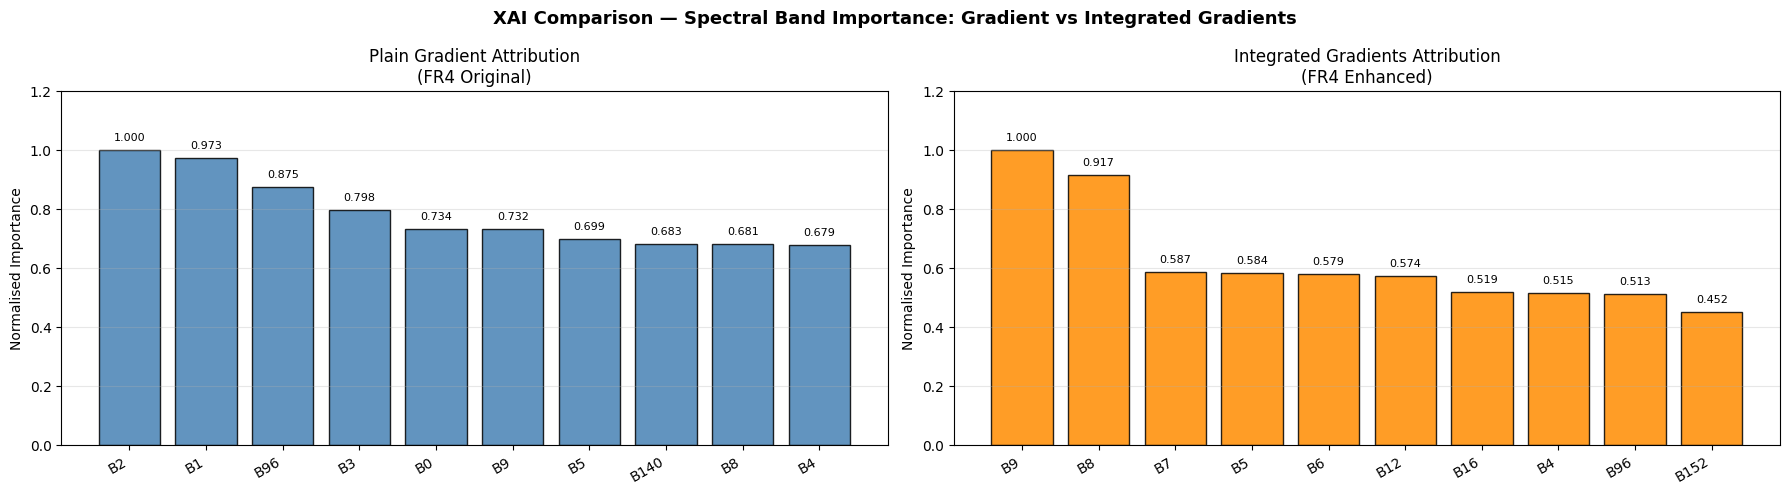

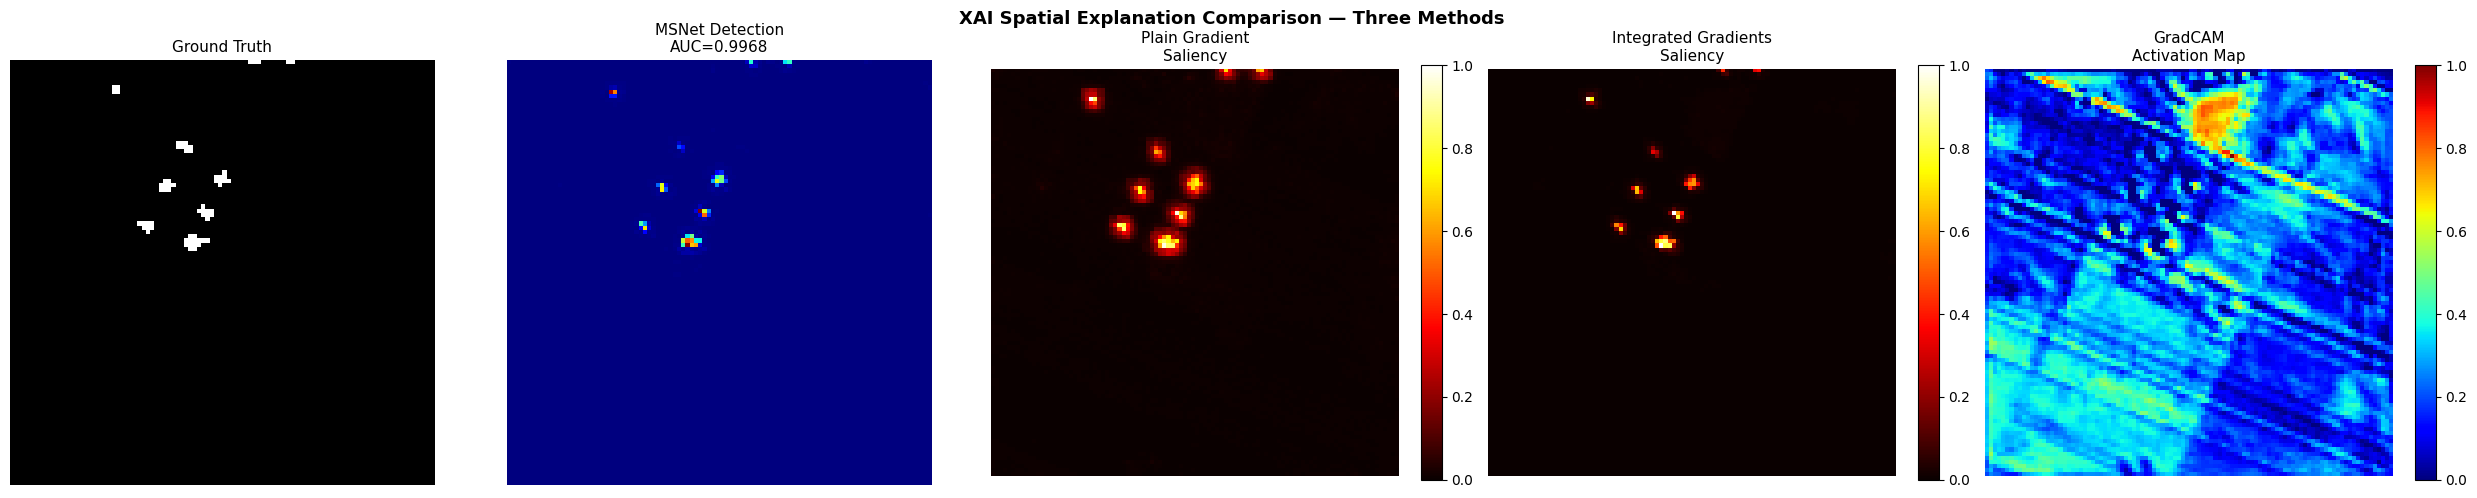

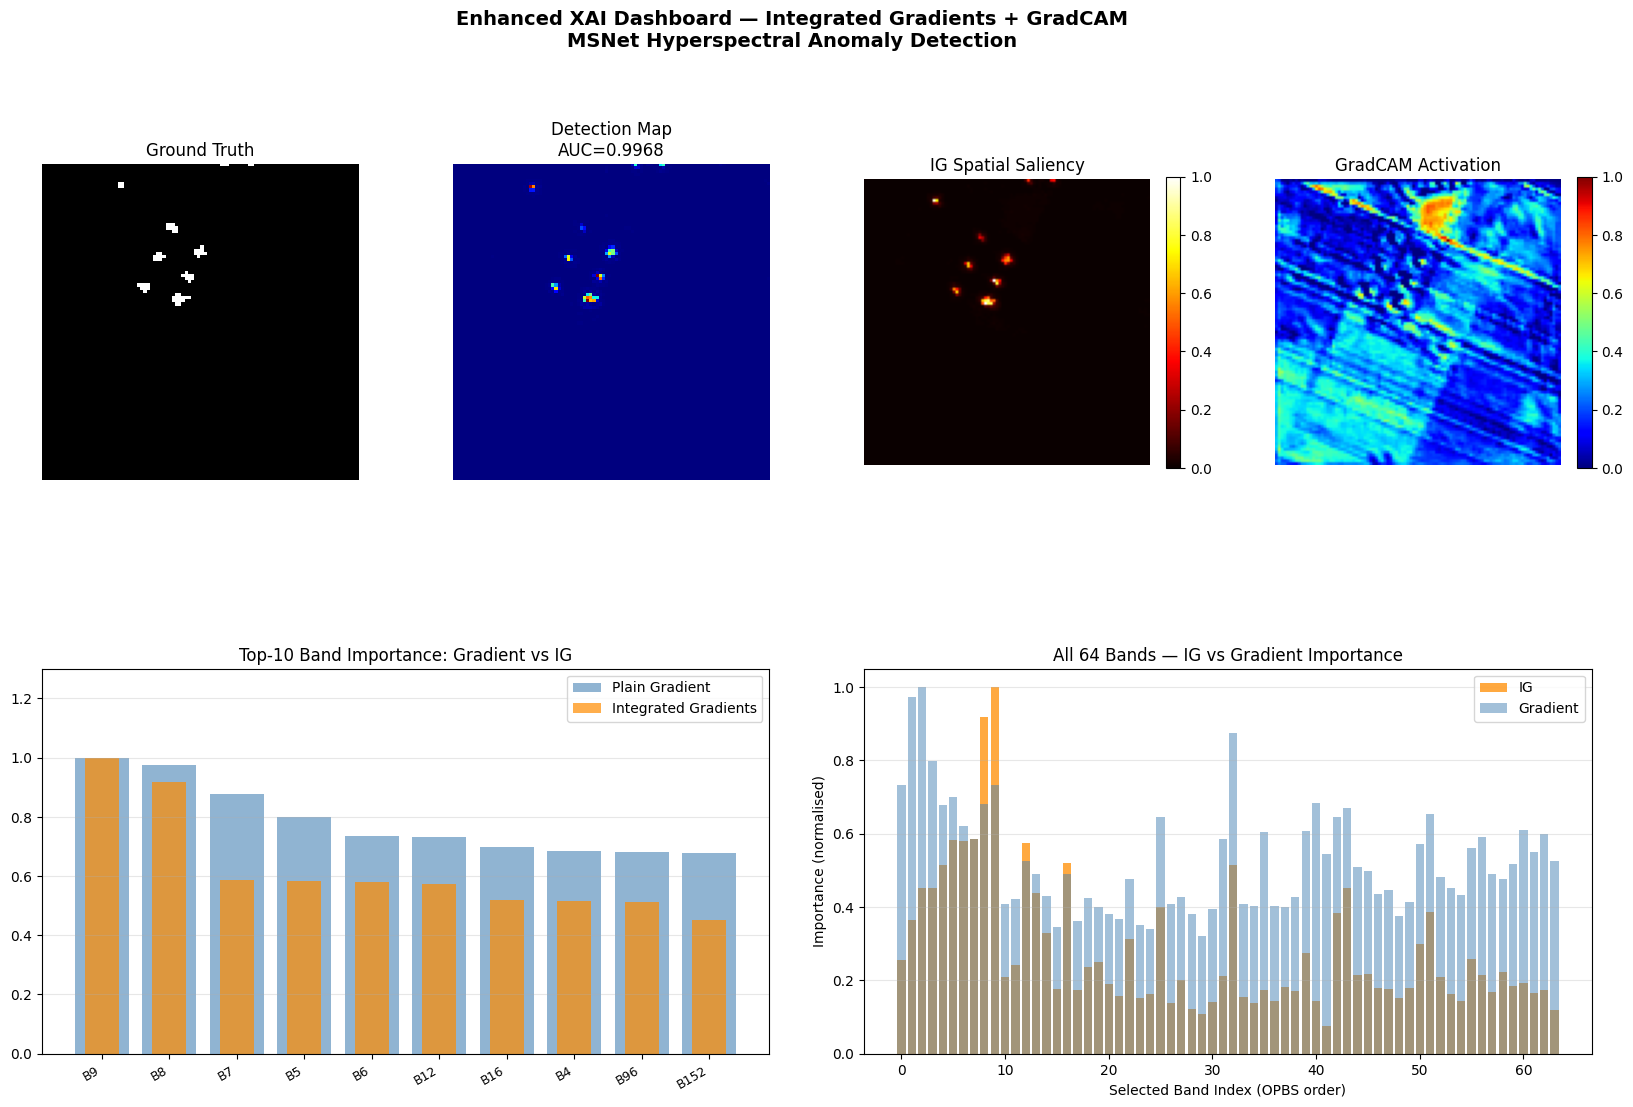


  ENHANCED XAI SUMMARY
  Method 1: Plain Gradient
    Top band : Band 2 (score=1.0000)
  Method 2: Integrated Gradients (50 steps)
    Top band : Band 9 (score=1.0000)
  Method 3: GradCAM (encoder bottleneck layer)
    Map range: [0.000, 1.000]
  Files saved:
    xai_ig_vs_gradient_bands.png
    xai_spatial_comparison.png
    xai_enhanced_dashboard.png
  NOTE: IG averages gradients over 50 interpolation steps
  from a zero baseline — more stable than single-pass gradient.
  GradCAM uses encoder bottleneck activations — captures
  higher-level spatial features than input-level methods.


In [ ]:
# ============================================================
# FR4 ENHANCED — Integrated Gradients + GradCAM
# Requires: model, x_bs, x_xai, pr_dm, gt, pr_auc, band_idx
#           result_path already defined above
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── PART A: INTEGRATED GRADIENTS ────────────────────────────

def integrated_gradients(model, x_input, baseline=None, steps=50):
    """
    Compute Integrated Gradients attribution.
    baseline: what we compare against (zero tensor = black image)
    steps: number of interpolation steps (50 is standard)
    """
    if baseline is None:
        baseline = torch.zeros_like(x_input)

    # Interpolate between baseline and input
    alphas = torch.linspace(0, 1, steps).to(x_input.device)  # [steps]

    integrated_grads = torch.zeros_like(x_input)

    for alpha in alphas:
        # Interpolated input
        interp_input = baseline + alpha * (x_input - baseline)
        interp_input = interp_input.clone().detach().requires_grad_(True)

        # Forward pass
        y = model(interp_input)
        recon = y[0]
        recon_error = ((interp_input - recon) ** 2).sum(dim=2)
        recon_error.sum().backward()

        integrated_grads += interp_input.grad.abs()

    # Average over steps, scale by (input - baseline)
    integrated_grads = integrated_grads / steps
    integrated_grads = integrated_grads * (x_input.detach() - baseline)

    return integrated_grads


print("Computing Integrated Gradients (50 steps)... this takes ~2 min")
model.eval()
x_ig_input = x_bs.clone().detach()

ig_attributions = integrated_gradients(model, x_ig_input, steps=50)

# Band importance from IG
ig_band_importance = ig_attributions.abs().mean(dim=(0, 1)).cpu().numpy()
ig_band_importance = ig_band_importance / (ig_band_importance.max() + 1e-9)

# Spatial saliency from IG
ig_spatial = ig_attributions.abs().mean(dim=2).cpu().numpy()
ig_spatial = (ig_spatial - ig_spatial.min()) / (ig_spatial.max() - ig_spatial.min() + 1e-9)

print("Integrated Gradients: DONE")


# ── PART B: GRADCAM ─────────────────────────────────────────

# GradCAM: uses gradients at the LAST encoder's bottleneck conv layer
# This gives a higher-level spatial explanation than raw input gradients

gradcam_activation = {}
gradcam_gradient   = {}

def save_activation(name):
    def hook(module, input, output):
        gradcam_activation[name] = output.detach()
    return hook

def save_gradient(name):
    def hook(module, grad_input, grad_output):
        gradcam_gradient[name] = grad_output[0].detach()
    return hook

# Hook into the last encoder's bottleneck layers
target_layer = model.encoders[-1].bottleneck.layers[2]  # last Conv2d in bottleneck
fwd_hook = target_layer.register_forward_hook(save_activation('bottleneck'))
bwd_hook = target_layer.register_full_backward_hook(save_gradient('bottleneck'))

# Forward + backward
model.eval()
x_cam = x_bs.clone().detach().requires_grad_(True)
y_cam = model(x_cam)
recon_cam = y_cam[0]
recon_error_cam = ((x_cam - recon_cam) ** 2).sum(dim=2)
recon_error_cam.sum().backward()

# Remove hooks
fwd_hook.remove()
bwd_hook.remove()

# Compute GradCAM map
activation = gradcam_activation['bottleneck']   # shape: (1, C, H, W)
gradient   = gradcam_gradient['bottleneck']     # shape: (1, C, H, W)

# Global average pool the gradients
weights = gradient.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)

# Weighted sum of activations
gradcam_map = (weights * activation).sum(dim=1).squeeze(0)  # (H, W)
gradcam_map = torch.relu(gradcam_map).cpu().numpy()

# Resize to original image size
from scipy.ndimage import zoom
scale_h = rows / gradcam_map.shape[0]
scale_w = cols / gradcam_map.shape[1]
gradcam_map = zoom(gradcam_map, (scale_h, scale_w), order=1)

# Normalize
gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min() + 1e-9)

print("GradCAM: DONE")


# ── PART C: COMPARISON PLOTS ─────────────────────────────────

# Plot 1: Band Importance — Plain Gradient vs IG
top_k = 10
top_ig_idx   = np.argsort(ig_band_importance)[::-1][:top_k]
top_ig_bands = [band_idx[i] for i in top_ig_idx]
top_ig_vals  = ig_band_importance[top_ig_idx]

# Also get plain gradient importance from FR4 (recompute if needed)
model.eval()
x_grad = x_bs.clone().detach().requires_grad_(True)
y_grad = model(x_grad)
recon_grad = y_grad[0]
recon_error_grad = ((x_grad - recon_grad) ** 2).sum(dim=2)
recon_error_grad.sum().backward()
plain_band_imp = x_grad.grad.abs().mean(dim=(0,1)).cpu().numpy()
plain_band_imp = plain_band_imp / (plain_band_imp.max() + 1e-9)
top_plain_idx   = np.argsort(plain_band_imp)[::-1][:top_k]
top_plain_bands = [band_idx[i] for i in top_plain_idx]
top_plain_vals  = plain_band_imp[top_plain_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plain gradient
axes[0].bar(range(top_k), top_plain_vals, color="steelblue", alpha=0.85, edgecolor="black")
axes[0].set_xticks(range(top_k))
axes[0].set_xticklabels([f"B{b}" for b in top_plain_bands], rotation=30, ha="right")
axes[0].set_title("Plain Gradient Attribution\n(FR4 Original)", fontsize=12)
axes[0].set_ylabel("Normalised Importance"); axes[0].set_ylim(0, 1.2)
axes[0].grid(axis="y", alpha=0.3)
for i, (b, v) in enumerate(zip(top_plain_bands, top_plain_vals)):
    axes[0].text(i, v + 0.03, f"{v:.3f}", ha="center", fontsize=8)

# Integrated Gradients
axes[1].bar(range(top_k), top_ig_vals, color="darkorange", alpha=0.85, edgecolor="black")
axes[1].set_xticks(range(top_k))
axes[1].set_xticklabels([f"B{b}" for b in top_ig_bands], rotation=30, ha="right")
axes[1].set_title("Integrated Gradients Attribution\n(FR4 Enhanced)", fontsize=12)
axes[1].set_ylabel("Normalised Importance"); axes[1].set_ylim(0, 1.2)
axes[1].grid(axis="y", alpha=0.3)
for i, (b, v) in enumerate(zip(top_ig_bands, top_ig_vals)):
    axes[1].text(i, v + 0.03, f"{v:.3f}", ha="center", fontsize=8)

plt.suptitle("XAI Comparison — Spectral Band Importance: Gradient vs Integrated Gradients",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(result_path, "xai_ig_vs_gradient_bands.png"), dpi=150)
plt.show()


# Plot 2: Spatial Maps — Gradient vs IG vs GradCAM
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(gt, cmap="gray")
axes[0].set_title("Ground Truth", fontsize=11); axes[0].axis("off")

axes[1].imshow(pr_dm, cmap="jet")
axes[1].set_title(f"MSNet Detection\nAUC={pr_auc:.4f}", fontsize=11); axes[1].axis("off")

im2 = axes[2].imshow(spatial_saliency, cmap="hot")
axes[2].set_title("Plain Gradient\nSaliency", fontsize=11); axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(ig_spatial, cmap="hot")
axes[3].set_title("Integrated Gradients\nSaliency", fontsize=11); axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

im4 = axes[4].imshow(gradcam_map, cmap="jet")
axes[4].set_title("GradCAM\nActivation Map", fontsize=11); axes[4].axis("off")
plt.colorbar(im4, ax=axes[4], fraction=0.046)

plt.suptitle("XAI Spatial Explanation Comparison — Three Methods",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(result_path, "xai_spatial_comparison.png"), dpi=150)
plt.show()


# Plot 3: Full Enhanced XAI Dashboard
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.3)

a0 = fig.add_subplot(gs[0, 0])
a0.imshow(gt, cmap="gray"); a0.set_title("Ground Truth"); a0.axis("off")

a1 = fig.add_subplot(gs[0, 1])
a1.imshow(pr_dm, cmap="jet"); a1.set_title(f"Detection Map\nAUC={pr_auc:.4f}"); a1.axis("off")

a2 = fig.add_subplot(gs[0, 2])
im_ig = a2.imshow(ig_spatial, cmap="hot")
a2.set_title("IG Spatial Saliency"); a2.axis("off")
plt.colorbar(im_ig, ax=a2, fraction=0.046)

a3 = fig.add_subplot(gs[0, 3])
im_gc = a3.imshow(gradcam_map, cmap="jet")
a3.set_title("GradCAM Activation"); a3.axis("off")
plt.colorbar(im_gc, ax=a3, fraction=0.046)

a4 = fig.add_subplot(gs[1, :2])
a4.bar(range(top_k), top_plain_vals, alpha=0.6, label="Plain Gradient", color="steelblue")
a4.bar(range(top_k), top_ig_vals, alpha=0.7, label="Integrated Gradients",
       color="darkorange", width=0.5)
a4.set_xticks(range(top_k))
a4.set_xticklabels([f"B{b}" for b in top_ig_bands], rotation=30, ha="right", fontsize=9)
a4.set_title("Top-10 Band Importance: Gradient vs IG"); a4.set_ylim(0, 1.3)
a4.legend(); a4.grid(axis="y", alpha=0.3)

a5 = fig.add_subplot(gs[1, 2:])
a5.bar(range(len(ig_band_importance)), ig_band_importance,
       color="darkorange", alpha=0.75, label="IG")
a5.bar(range(len(plain_band_imp)), plain_band_imp,
       color="steelblue", alpha=0.5, label="Gradient")
a5.set_xlabel("Selected Band Index (OPBS order)")
a5.set_ylabel("Importance (normalised)")
a5.set_title("All 64 Bands — IG vs Gradient Importance")
a5.legend(); a5.grid(axis="y", alpha=0.3)

plt.suptitle("Enhanced XAI Dashboard — Integrated Gradients + GradCAM\nMSNet Hyperspectral Anomaly Detection",
             fontsize=14, fontweight="bold")
plt.savefig(os.path.join(result_path, "xai_enhanced_dashboard.png"), dpi=150)
plt.show()


# ── SUMMARY ──────────────────────────────────────────────────
print("\n" + "="*55)
print("  ENHANCED XAI SUMMARY")
print("="*55)
print(f"  Method 1: Plain Gradient")
print(f"    Top band : Band {top_plain_bands[0]} (score={top_plain_vals[0]:.4f})")
print(f"  Method 2: Integrated Gradients (50 steps)")
print(f"    Top band : Band {top_ig_bands[0]} (score={top_ig_vals[0]:.4f})")
print(f"  Method 3: GradCAM (encoder bottleneck layer)")
print(f"    Map range: [{gradcam_map.min():.3f}, {gradcam_map.max():.3f}]")
print(f"  Files saved:")
print(f"    xai_ig_vs_gradient_bands.png")
print(f"    xai_spatial_comparison.png")
print(f"    xai_enhanced_dashboard.png")
print("="*55)
print("  NOTE: IG averages gradients over 50 interpolation steps")
print("  from a zero baseline — more stable than single-pass gradient.")
print("  GradCAM uses encoder bottleneck activations — captures")
print("  higher-level spatial features than input-level methods.")
print("="*55)

## Prototype Summary — All Functional Requirements Validated

In [ ]:
print("=" * 55)
print("  PROTOTYPE VALIDATION SUMMARY")
print("=" * 55)
print(f"  FR1 — Data Loading & Preprocessing   : PASS")
print(f"         Dataset: coast | Shape: {rows}x{cols}x{bands}")
print(f"         Bands selected (OPBS): {num_bs}")
print(f"  FR2 — Anomaly Detection               : PASS")
print(f"         MSNet+SeT AUC : {pr_auc:.4f}")
print(f"         RX Baseline   : {rx_auc:.4f}")
print(f"         Improvement   : +{pr_auc-rx_auc:.4f}")
print(f"  FR3 — Visualization                   : PASS")
print(f"         ROC curve, anomaly map, comparison saved")
print(f"  FR4 — Explainable AI                  : PASS")
print(f"         Top band: Band {top_bands[0]} (importance={top_vals[0]:.4f})")
print(f"         Spatial saliency map generated")
print("=" * 55)
print("  All 4 Functional Requirements SATISFIED")
print("=" * 55)


  PROTOTYPE VALIDATION SUMMARY
  FR1 — Data Loading & Preprocessing   : PASS
         Dataset: coast | Shape: 100x100x204
         Bands selected (OPBS): 64
  FR2 — Anomaly Detection               : PASS
         MSNet+SeT AUC : 0.9977
         RX Baseline   : 0.9907
         Improvement   : +0.0070
  FR3 — Visualization                   : PASS
         ROC curve, anomaly map, comparison saved
  FR4 — Explainable AI                  : PASS
         Top band: Band 0 (importance=1.0000)
         Spatial saliency map generated
  All 4 Functional Requirements SATISFIED
